In [64]:
import yfinance as yf
import pandas as pd

#Fetch data
def fetch_market_data(start="2015-01-02", end = None):
    #User input validation
    try:
        tickers = input("Enter 2 ticker as per yahoo: ").strip().replace(',',' ').split() #returns a list
        if len(tickers) != 2:
            raise ValueError("Enter only 2 tickers.")
    except ValueError as e:
        print(f"Error: {e}")

    #Data download validation
    try:
        df = yf.download(tickers, start=start, end=end, group_by="ticker")
    except:
        print("Error in downloading.....")
    
    if (tickers[0] not in df.columns) or (tickers[1] not in df.columns):
        print("Ticker not found")
            
    if ((df[tickers[1]]["Close"]).isna().all()) or (df[tickers[0]]["Close"]).isna().all():
        print("No valid price data")

    ticker1 = df[tickers[0]]["Close"]
    ticker2 = df[tickers[1]]["Close"]

    data = pd.DataFrame({
        tickers[0]: ticker1,
        tickers[1] : ticker2
    })

    data = data.ffill()
    return data, tickers

In [65]:
data,tickers = fetch_market_data()
data.sample(5)

[*********************100%***********************]  2 of 2 completed


,GC=F,EURUSD=X
Date,,
2026-04-03,4651.500000,1.154175
2022-02-16,1870.199951,1.135680
2016-06-15,1285.800049,1.121302
2020-04-01,1578.199951,1.102657
2017-06-06,1294.400024,1.125682


In [66]:
print(data.shape)
data.describe()

(2962, 2)


,GC=F,EURUSD=X
count,2962.000000,2962.000000
mean,1867.193010,1.121726
std,846.195114,0.052037
min,1050.800049,0.959619
25%,1274.599976,1.085700
50%,1725.049988,1.119395
75%,1962.650024,1.163596
max,5318.399902,1.251001


In [ ]:
df = data.copy()
df[tickers[0] +'_pct_change']=df[tickers[0]].pct_change()*100
df[tickers[1] +'_pct_change']=df[tickers[1]].pct_change()*100

In [71]:
import matplotlib.pyplot as plt
def plot_pct_change(data, events = None):
    df[[tickers[0] +'_pct_change',tickers[1] +'_pct_change']].plot(figsize=(12,6),title = 'Daily % Change with Global Events')
    
    if events:
        for event in events:
            dt = pd.to_datetime(event['date'])
            plt.axvline(dt, color = 'red', linestyle ='--',alpha=0.7)
            plt.annotate(event['label'],
                 xy=(dt, plt.ylim()[1]),
                 xytext=(dt, plt.ylim()[1]*0.6),
                 fontsize=8, rotation=50)
            
    plt.show()

In [72]:
events = pd.read_csv("events.csv").to_dict('records')

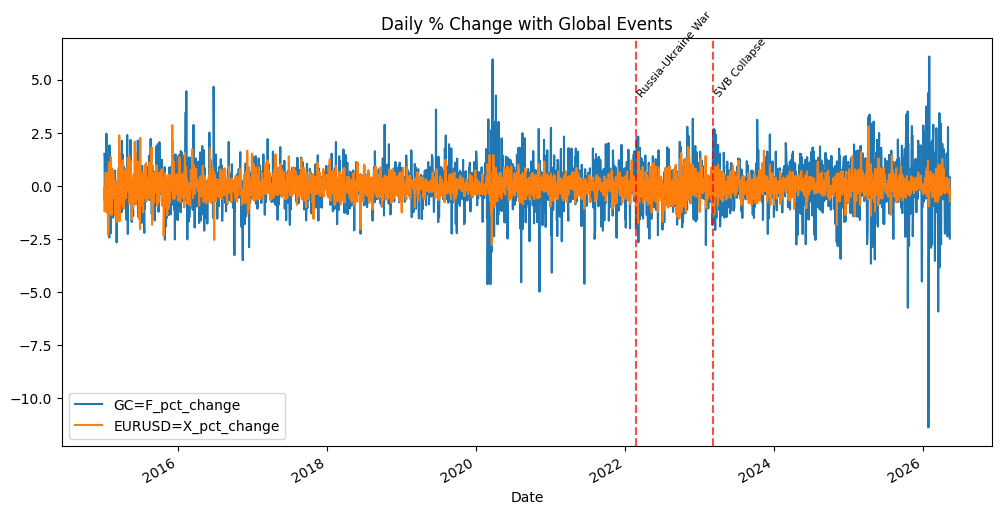

In [73]:
plot_pct_change(data,events)

In [74]:
flight_days = df[(df[tickers[0]+'_pct_change'] > 0) & (df[tickers[1]+'_pct_change'] < 0)]
def detect_flight_to_safety(df):
    result = {
        "flight_days": flight_days.shape[0],
        "percentage":round((flight_days.shape[0]/ len(df)) * 100, 2),
        "data": flight_days
    }
    return result

In [79]:
result = detect_flight_to_safety(df)
print("Number of flight to safety days", result["flight_days"])
print("Percentage:", result["percentage"],"%")
result["data"][[tickers[0]+'_pct_change', tickers[1]+'_pct_change']].sample(5)

Number of flight to safety days 759
Percentage: 25.62 %


,GC=F_pct_change,EURUSD=X_pct_change
Date,,
2016-02-23,1.058293,-0.862395
2025-07-18,0.386213,-0.174228
2019-03-06,0.226211,-0.266843
2025-06-18,0.094489,-0.594801
2026-02-27,1.043176,-0.102691


In [10]:
flight_days.loc[:,"year"]=flight_days.index.year
flight_days["year"].value_counts().sort_index()

year
2015    54
2016    61
2017    72
2018    54
2019    68
2020    65
2021    65
2022    73
2023    53
2024    83
2025    82
2026    22
Name: count, dtype: int64

2022-02-24: found
2023-03-10: not found in flight_days


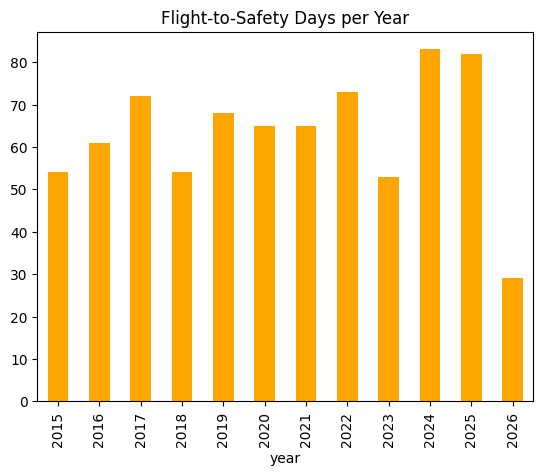

In [84]:
flight_days['year'] = pd.to_datetime(flight_days.index).year

flight_days['year'].value_counts().sort_index().plot(kind='bar',title='Flight-to-Safety Days per Year', color='orange')
for event in events:
    if event['date'] in flight_days.index:
        print(f"{event['date']}: found")
    else:
        print(f"{event['date']}: not found in flight_days")


### Flight-to-Safety Analysis Summary

This chart shows the number of "Flight-to-Safety" days per year — when Gold prices rose while EUR/USD fell.

- In **2022**, heightened geopolitical uncertainty (e.g., Ukraine invasion in February) triggered frequent capital flows into gold.
- In **2023**, fewer such days were observed, despite events like the SVB collapse in March, suggesting a relatively calmer macroeconomic environment.
- In **2024**, there's a clear increase again, possibly due to inflation fears, rate changes, or geopolitical tensions.

This supports the theory that gold serves as a haven asset in periods of global stress.
